In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")



In [3]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [4]:
# Senaryo -> Bir şehir meydanında belirli bir zamanda yayaların konumlarını analiz etmeye çalışıyoruz.

# Her nokta bir kişiyi temsil ediyor. Kümeleme, doğal grupları veya yoğun alanları keşfetmemize yardımcı olacaktır.
# Burada true_cluster sütunumuz var. Bu aslında bir etiket. Yani bu bir kümeleme veri seti değil.
# Bu bir sınıflandırma problemi. Ancak true_cluster sütununu yok sayacağız.
# Ve bu sütun yokmuş gibi, true_cluster etiketi olmadan yayaları nasıl kümeleyebileceğimizi göreceğiz.
# Daha sonra, dbscan'in çalışıp çalışmadığını değerlendirmek için bu sütunu kullanacağız.

# Gerçek hayattaki bir senaryoda, başarıyı belirlemek için Silhouette gibi kümeleme performans ölçütlerine ihtiyacımız olacaktır.

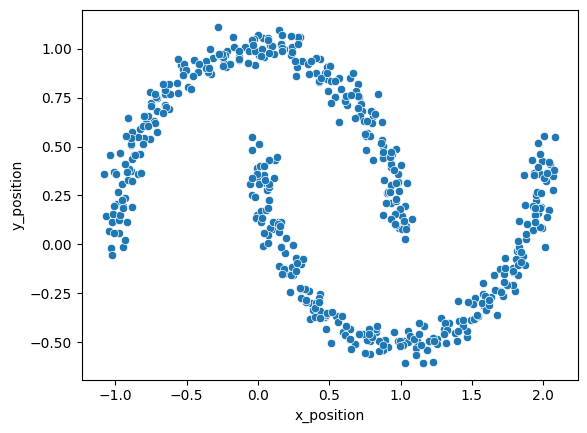

In [6]:

sns.scatterplot(data=df, x="x_position", y="y_position")
plt.show()


In [7]:
df = df.drop("true_cluster", axis=1)


In [8]:
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   x_position  500 non-null    float64
 1   y_position  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [11]:
X_scaled=scaler.fit_transform(df)


In [12]:
from sklearn.cluster import DBSCAN


In [13]:
dbscan = DBSCAN()


Parameters
eps : float, default=0.5 The maximum distance between two samples for one to be considered as in the neighborhood of the other. This is not a maximum bound on the distances of points within a cluster. This is the most important DBSCAN parameter to choose appropriately for your data set and distance function.

min_samples : int, default=5 The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself. If min_samples is set to a higher value, DBSCAN will find denser clusters, whereas if it is set to a lower value, the found clusters will be more sparse.



In [14]:
dbscan.fit(X_scaled)


DBSCAN()

In [15]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [16]:

# Sonuçları görselleştirelim

In [17]:
X_scaled = pd.DataFrame(X_scaled, columns = ["x_position", "y_position"])


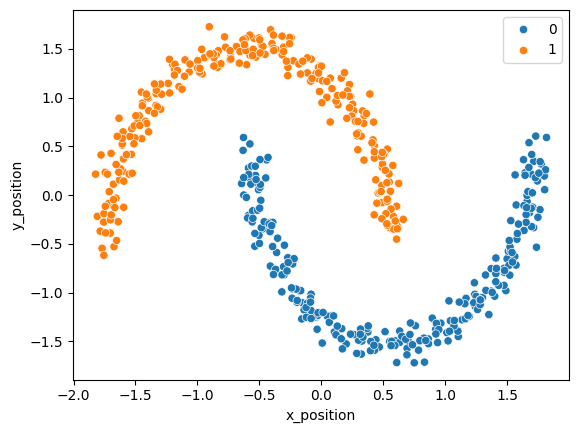

In [18]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbscan.labels_)
plt.show()

In [19]:
# Orijinal etiketlerle karşılaştıralım (gerçek hayatta bu seçeneğimiz yok)
# Ama çalışıp çalışmadığına bakalım

In [20]:
df = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")


In [21]:
df.columns


Index(['x_position', 'y_position', 'true_cluster'], dtype='object')

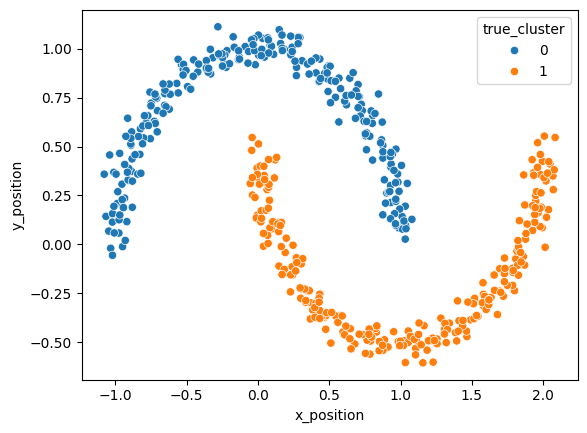

In [22]:
sns.scatterplot(data=df, x="x_position", y="y_position", hue="true_cluster")
plt.show()

In [23]:
# Gördüğünüz gibi aynı sonucu veriyor.


In [24]:

# Açıkçası, hiperparametre ayarlaması yapmamız gereken bir durumla karşılaşabilirdik

In [25]:
# Hyperparameter grids
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6]
min_samples_values = [4,5,6]

In [26]:
from sklearn.metrics import silhouette_score


In [27]:
# Store results
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_
        # Skip if all points are noise or only one cluster found
        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })

# Convert to DataFrame and sort by silhouette 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [28]:
results_df


,eps,min_samples,Silhouette,n_clusters
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2
16,0.6,5,0.389338,2
15,0.6,4,0.389338,2
14,0.5,6,0.389338,2
13,0.5,5,0.389338,2
12,0.5,4,0.389338,2
11,0.4,6,0.389338,2
17,0.6,6,0.389338,2
8,0.3,6,0.389338,2


In [29]:

# dbscan yerine hdbscan ile aynı şeyi deneyelim

In [30]:
from sklearn.cluster import HDBSCAN


In [31]:
hdbscan = HDBSCAN()


min_cluster_size : int, default=5 The minimum number of samples in a group for that group to be considered a cluster; groupings smaller than this size will be left as noise.

min_samples : int, default=None The parameter k used to calculate the distance between a point x_p and its k-th nearest neighbor. When None, defaults to min_cluster_size.

In [32]:

# Daha önce de belirttiğimiz gibi hdbscan'de epsilon yok, bu yüzden önce herhangi bir hiperparametre ayarı yapmadan bunu deneyelim.

In [33]:
hdbscan.fit(X_scaled)


HDBSCAN()

In [34]:
hdbscan.labels_


array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

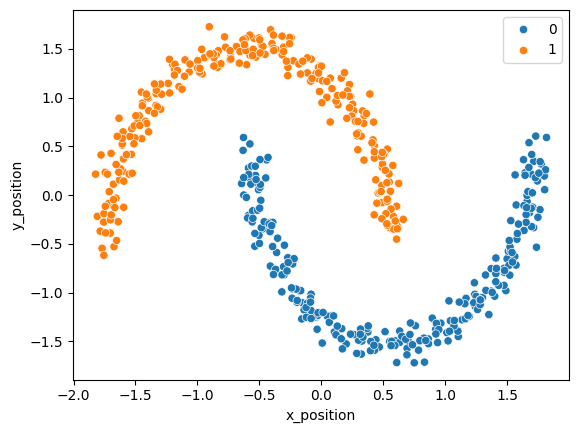

In [35]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=hdbscan.labels_)
plt.show()

In [36]:
# Gördüğünüz gibi, hdbscan de harika çalışıyor.
#Eğer hiperparametre ayarlaması yapmamız gerekseydi, aynı şekilde yapabilirdik.

In [37]:

min_cluster_sizes = [3, 5, 7, 10]
min_samples = [None, 3, 5, 7]

In [38]:
results = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_
        # Skip if all points are noise or only one cluster found
        if len(set(labels)) <= 1:
            continue
        
        silhouette = silhouette_score(X_scaled, labels)
        
        results.append({
            'min_cluster_size': min_cluster,
            'min_samples': min_sample,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })

# Convert to DataFrame and sort by silhouette 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [39]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
2,3,5.0,0.389338,2
3,3,7.0,0.389338,2
4,5,NaN,0.389338,2
5,5,3.0,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
8,7,NaN,0.389338,2
9,7,3.0,0.389338,2
10,7,5.0,0.389338,2
11,7,7.0,0.389338,2
